In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import non_negative_factorization
from scipy.interpolate import make_interp_spline

## Age-Associated Dynamics of Functional ESs

### Resolve H using fixed W and complete dataset

In [4]:
k = 7
data_type = 'functions' # choices: 'functions', 'genera'

results_path = f"../results/{data_type}/random_split/nmf_trained/nsig_{k}"

In [5]:
# Resolve matrix H (topics x samples) through NMF using W (features x topics) and original matrix X (features x samples)
W_path = f'{results_path}/best_run/W_{k}.csv'
W = pd.read_csv(W_path, index_col=0)

X_train = pd.read_csv('../data/functions/random_split/processed/train.tsv', sep='\t',index_col=0)
X_test = pd.read_csv('../data/functions/random_split/processed/test.tsv', sep='\t', index_col=0)
X_val = pd.read_csv('../data/functions/random_split/processed/val.tsv', sep='\t', index_col=0)

X = pd.concat([X_train, X_test, X_val], axis = 0)
X = X[W.index]

In [ ]:
# Resolve H using fixed W
X_array = X.values
H_array = W.T.values

print(f"X shape: {X_array.shape}")
print(f"H init shape: {H_array.shape}")

H_nmf, W_nmf, n_iter = non_negative_factorization(
    X_array,
    n_components=k,
    init='custom',
    H=H_array,
    update_H=False,
    solver='mu',
    beta_loss='kullback-leibler',
    max_iter=2000,
    random_state=42
)


print("H_nmf:", H_nmf.shape)

H = pd.DataFrame(H_nmf.T,
                 index=W.columns,
                 columns=X.index)

print("H shape:", H.shape)

H.to_csv(f'{results_path}/best_run/H_{k}_all_samples.csv')

### Distribution of mean relative abundances (%) of functional ESs across age

In [7]:
H_path = f'{results_path}/best_run/H_{k}_all_samples.csv'
H = pd.read_csv(H_path, index_col=0)
H.index = [i for i in range(1, k + 1)]

metadata = pd.read_csv("../data/metadata.tsv", sep="\t", index_col=None)
metadata = metadata.set_index('sample_id')

In [8]:
# By normalizing the H matrix column-wise, we obtained the relative abundance of ES in each sample. We define as primary ES the ES of a sample with the highest relative abundance.
H_norm = H.div(H.sum(axis=0), axis=1) * 100
H_norm = H_norm.T

In [14]:
# Keep only samples present in both H_norm and metadata
common_samples = H_norm.index.intersection(metadata.index)

H_train_norm_clean = H_norm.loc[common_samples].copy()
metadata = metadata.loc[common_samples].copy()

# Match metadata to H_train_norm samples
age = metadata['age']
age_category = metadata['age_category']

# Get signature names
signatures = list(H_train_norm_clean.columns)

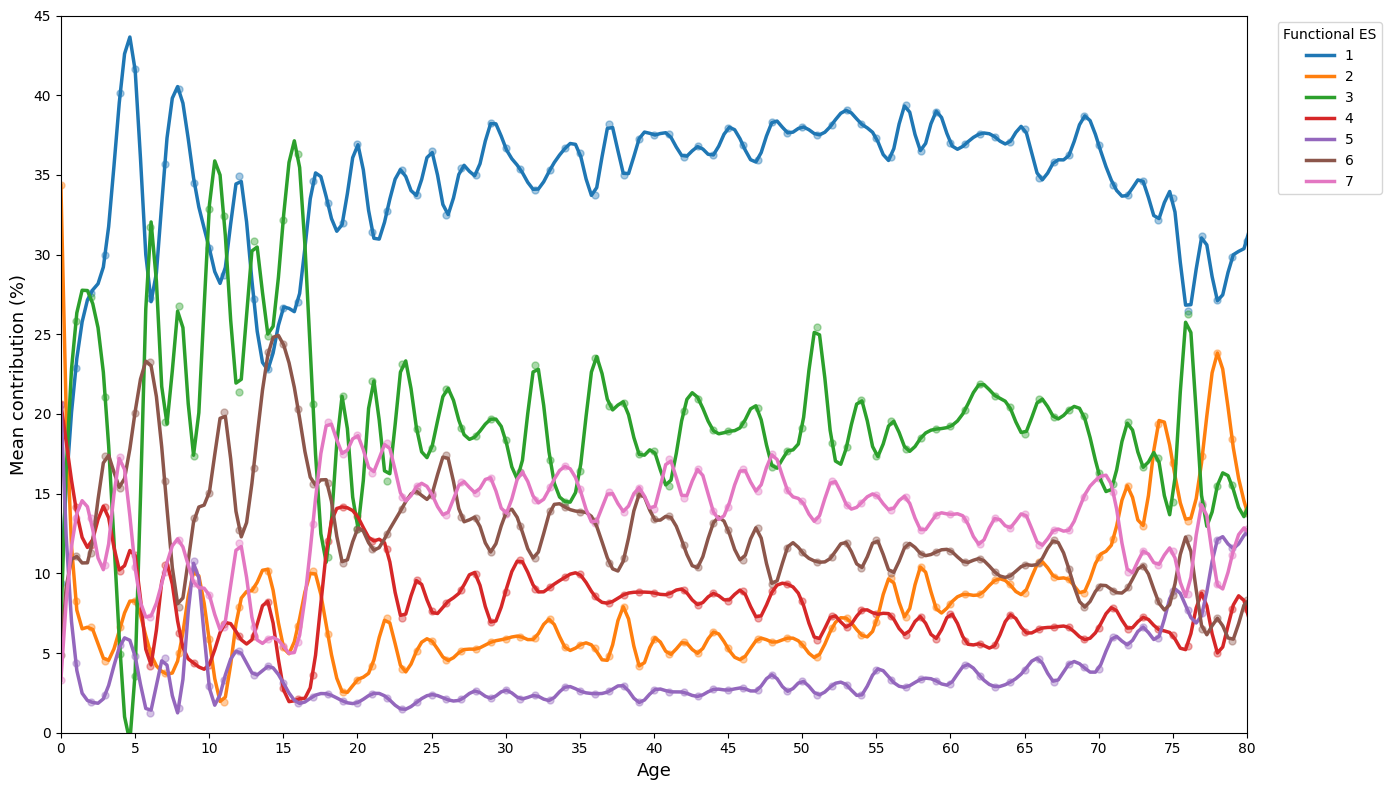

In [ ]:
ESs = list(H_train_norm_clean.columns)

plt.figure(figsize=(14, 8))

palette = sns.color_palette("tab10", n_colors=len(ESs))

for es, color in zip(ESs, palette):

    # Contribution of this ES for each sample
    df = pd.DataFrame({'Age': age.values, 'Contribution': H_train_norm_clean[es].values})

    # Mean contribution per age
    mean_data = (df.groupby('Age')['Contribution'].mean().reset_index().sort_values('Age'))
    x = mean_data['Age'].values
    y = mean_data['Contribution'].values

    # Smooth curve
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_smooth)

    plt.plot(x_smooth, y_smooth, linewidth=2.5, color=color, label=es)

    plt.scatter(x, y, color=color, s=25, alpha=0.4)

plt.xlabel('Age', fontsize=13)
plt.ylabel('Mean contribution (%)', fontsize=13)
plt.title('', fontsize=15)

plt.xticks(np.arange(0, 110, 5))
plt.ylim(0, 45)
plt.xlim(0,80)

plt.legend(title='Functional ES', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../images/age.png', dpi=500)
plt.show()

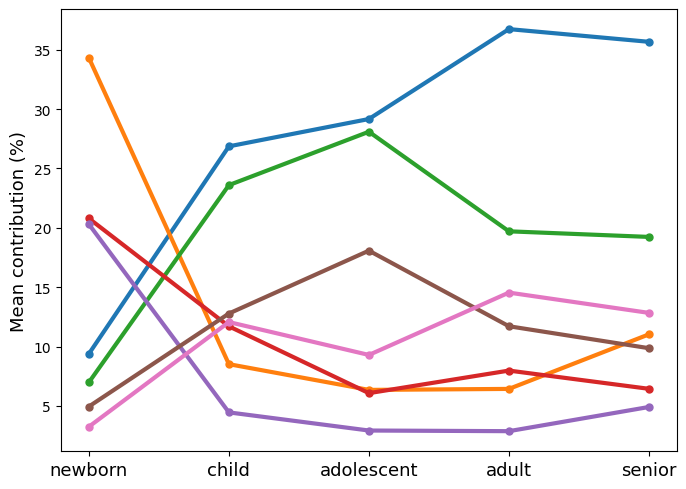

In [ ]:
age_order = ['newborn', 'child', 'adolescent', 'adult', 'senior']

plt.figure(figsize=(7, 5))

palette = sns.color_palette("tab10", n_colors=len(ESs))

for es, color in zip(ESs, palette):

    # Contribution of this ES for each sample
    df = pd.DataFrame({'Age': age_category.values, 'Contribution': H_train_norm_clean[es].values})
    df['Age'] = pd.Categorical(df['Age'], categories=age_order, ordered=True)

    # Mean contribution per age
    mean_data = (df.groupby('Age', observed=False)['Contribution'].mean().reindex(age_order).dropna())
    x = np.arange(len(mean_data))
    y = mean_data.values

    plt.plot(x, y, marker='o', linewidth=3, markersize=5, color=color, label=es)

# Set age category 
plt.xticks(np.arange(len(age_order)), age_order, fontsize=13)

plt.ylabel('Mean contribution (%)', fontsize=13)

plt.savefig('../images/age_category.png', dpi=300)
plt.tight_layout()
plt.show()